In [130]:
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation, PauliGate
import numpy as np 
# A = np.array([[ 1.5 , -0.25,  0.  ,  0.  ],
#               [-0.25,  1.5 , -0.25,  0.  ],
#               [ 0.  , -0.25,  1.5 , -0.25],
#               [ 0.  ,  0.  , -0.25,  1.5 ]])

a = 0.25
b = 0.75

# matrix to be decomposed
A = np.array(
    [[a,  0, 0,  b],
     [0, -a, b,  0],
     [0,  b, a,  0],
     [b,  0, 0, -a]]
)

pauli_op = SparsePauliOp.from_operator(A)
pauli_op

SparsePauliOp(['IZ', 'XX'],
              coeffs=[0.25+0.j, 0.75+0.j])

In [172]:
print(A)

[[ 0.25  0.    0.    0.75]
 [ 0.   -0.25  0.75  0.  ]
 [ 0.    0.75  0.25  0.  ]
 [ 0.75  0.    0.   -0.25]]


In [307]:
# convert |0>^k -----> Sum( c_i|i>) 
# U∣0⟩=k∑​ak​∣k⟩
n_ancilla = int(np.ceil(np.log2(len(pauli_op.coeffs))))
n_reg = int(np.log2(len(A)))
amps = np.sqrt(np.abs(pauli_op.coeffs) / np.linalg.norm(pauli_op.coeffs,ord=1))
padded_amps = np.zeros(2**n_ancilla)
padded_amps[:len(amps)] = amps
prep_gate = StatePreparation(padded_amps,label="Prep")
prep_gate

Instruction(name='state_preparation', num_qubits=1, num_clbits=0, params=[(0.5+0j), (0.8660254037844386+0j)])

In [ ]:
def selection_circuit(qc: QuantumCircuit, pauli_op : SparsePauliOp):
    for index, pauli in enumerate(pauli_op.paulis):
        intstr = f"{int(index):0{len(qc.qubits[:n_ancilla])}b}"[::-1]
        control_pauli_k = PauliGate(pauli.to_label()).control(num_ctrl_qubits=n_ancilla,ctrl_state=intstr)
        qc.append(control_pauli_k,qc.qubits)

    print("Selection")
    print(np.real(Operator(qc).to_matrix()))
    return qc


In [239]:
Operator(prep_gate).to_matrix()

array([[ 0.5      +0.j, -0.8660254+0.j],
       [ 0.8660254+0.j,  0.5      +0.j]])

In [308]:
ψ = np.array([1,0,0,0])

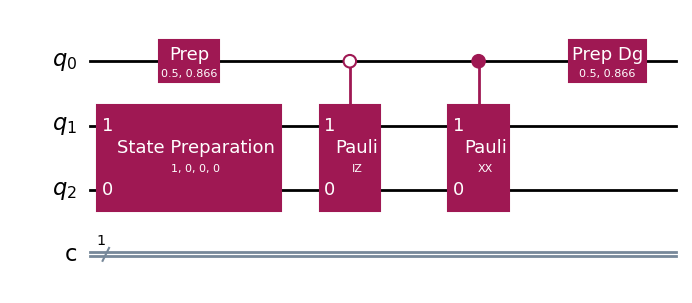

In [316]:
qc  = QuantumCircuit(n_ancilla + n_reg,n_ancilla)
qc.prepare_state(ψ,list(reversed(qc.qubits[n_ancilla:])))
qc.append(prep_gate,qc.qubits[:n_ancilla])

for index, pauli in enumerate(pauli_op.paulis):
    intstr = f"{int(index):0{len(qc.qubits[:n_ancilla])}b}"
    control_pauli_k = PauliGate(pauli.to_label()).control(num_ctrl_qubits=n_ancilla,ctrl_state=intstr)

    qbs = qc.qubits[:n_ancilla] + list(reversed(qc.qubits[n_ancilla:]))
    qc.append(control_pauli_k,qbs)

qc.append(prep_gate.inverse(),qc.qubits[:n_ancilla])
# qc.measure(qc.qubits[:n_ancilla],qc.clbits)
qc.draw("mpl")


In [315]:
U = Operator(qc).to_matrix()
print(np.real(np.round(U[:4,:4] * np.linalg.norm(pauli_op.coeffs,ord=1),2)))

[[ 0.25 -0.43  0.    0.  ]
 [-0.43  0.75  0.    0.  ]
 [ 0.    0.    0.25 -0.43]
 [ 0.    0.   -0.43  0.75]]


In [207]:
sv = Statevector(qc)
sv.draw('text')   

[ 2.50000000e-01+0.j,-4.33012702e-01+0.j, 2.53663409e-18+0.j,
 -4.39357912e-18+0.j,-2.32693832e-17+0.j,-1.34345847e-17+0.j,
  7.50000000e-01+0.j, 4.33012702e-01+0.j]

In [205]:
n = 3  # total qubits
for i in range(2**n):
    sv = Statevector.from_label(f"{i:0{n}b}")
    print(f"|{i:0{n}b}⟩ → index {np.argmax(np.abs(sv.data))}")

|000⟩ → index 0
|001⟩ → index 1
|010⟩ → index 2
|011⟩ → index 3
|100⟩ → index 4
|101⟩ → index 5
|110⟩ → index 6
|111⟩ → index 7


In [ ]:
def selection_matrix(pauli_op : SparsePauliOp):
    dim = len[pauli_op.coeffs]
    select_matrix = None
    for i in range(dim):
        u_k = pauli_op.paulis[i].to_matrix()
        ket_i = Statevector.from_int(i, dim).data
        outer_product = np.outer(ket_i,ket_i.conj())

        if not select_matrix:
            select_matrix = np.kron(outer_product,u_k)
        else:
            select_matrix = select_matrix + np.kron(outer_product,u_k)
    return select_matrix
